# 分類Fashion_mnist圖片



In [2]:
%pip install tensorflow numpy matplotlib -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# 載入所需環境
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2025-11-08 17:03:17.575870: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-08 17:03:17.621779: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-08 17:03:18.554789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load Dataset

In [4]:
# 載入fashion mnist dataset 有70000張灰階影像 10個類別 28*28像素
fashion_mnist = tf.keras.datasets.fashion_mnist

In [5]:
# 讀取數據
(train_images , train_labels), (test_images, test_labels ) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

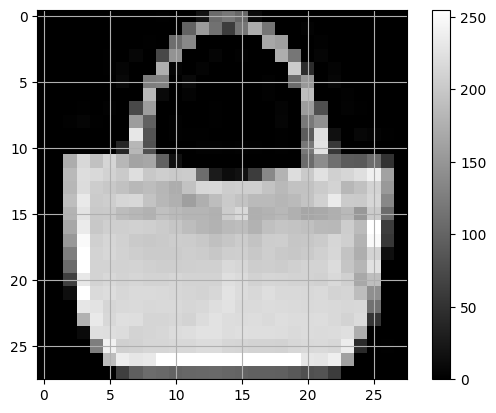

In [8]:
# 檢查數據讀取
plt.figure()
plt.imshow(train_images[100],cmap="gray")
plt.colorbar() # 新增色彩條
plt.grid(True) # 繪出網格線
plt.show()

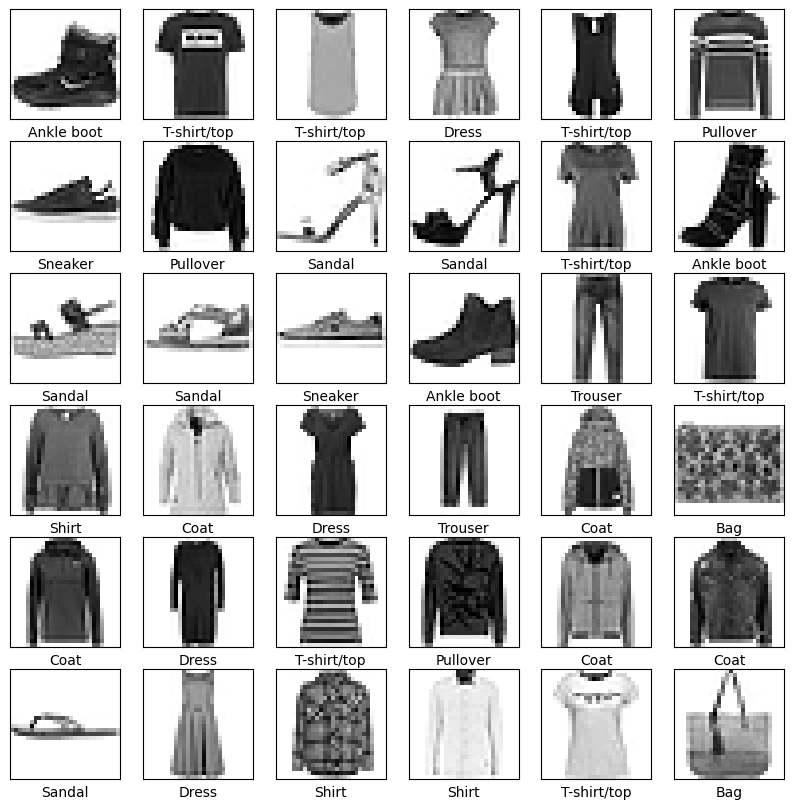

In [9]:
# 讓輸入的訓練集數值都介於0，1之間
train_images = train_images / 255.0
test_images = test_images / 255.0

# 畫出36張圖片
plt.figure(figsize=(10,10))
for i in range(36):
  plt.subplot(6,6,i+1)

  plt.xticks([]) # 隱藏x軸刻度
  plt.yticks([]) # 隱藏y軸刻度
  plt.grid(False) # 不顯示網格線

  plt.imshow(train_images[i],cmap=plt.cm.binary) # 畫出圖片，cmap=二值化顏色(灰階)

  plt.xlabel(class_names[train_labels[i]])
plt.show()

# Task
Design a neural network classifier to classify the provided data, split the data into 8:1:1 training, validation, and test sets, train the model, and plot the learning curve.

## Data splitting

### Subtask:
Split the data into training, validation, and test sets with an 8:1:1 ratio.


**Reasoning**:
Determine the size of the validation and test sets, then split the data accordingly.



In [23]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# 先把兩包合起來（70000 總數）
import numpy as np

all_images = np.concatenate([train_images, test_images], axis=0)
all_labels = np.concatenate([train_labels, test_labels], axis=0)

total = len(all_images)  # 70000
train_size = int(0.8 * total)  # 56000
val_size = int(0.1 * total)  # 7000
test_size = total - train_size - val_size  # 7000

train_images = all_images[:train_size]
train_labels = all_labels[:train_size]
val_images = all_images[train_size : train_size + val_size]
val_labels = all_labels[train_size : train_size + val_size]
test_images = all_images[train_size + val_size :]
test_labels = all_labels[train_size + val_size :]

print(f"Training set size: {len(train_images)}")  # 48000
print(f"Validation set size: {len(val_images)}")  # 6000
print(f"Test set size: {len(test_images)}")  # 10000

Training set size: 56000
Validation set size: 7000
Test set size: 7000


## Model design

### Subtask:
Design a neural network classifier using TensorFlow Keras.


In [29]:
from tensorflow.keras.layers import Flatten, Dense

model = tf.keras.Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,690 (655.04 KB)

 Trainable params: 167,690 (655.04 KB)

 Non-trainable params: 0 (0.00 B)

## Model training

### Subtask:
Train the designed model using the training data and validate it using the validation data.


In [30]:
epochs = 20
history = model.fit(train_images, train_labels, epochs=epochs, validation_data=(val_images, val_labels))

Epoch 1/20


2025-11-08 17:13:51.373578: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-08 17:13:51.373610: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-08 17:13:51.373621: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-08 17:13:51.373630: I external/l

1744/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.6914 - loss: 4.0927

2025-11-08 17:13:56.367987: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-08 17:13:56.368018: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-08 17:13:56.876440: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_39', 292 bytes spill stores, 292 bytes spill loads



1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7454 - loss: 1.3633 - val_accuracy: 0.8214 - val_loss: 0.5279
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 940us/step - accuracy: 0.8191 - loss: 0.5177 - val_accuracy: 0.8293 - val_loss: 0.4964
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 897us/step - accuracy: 0.8409 - loss: 0.4536 - val_accuracy: 0.8384 - val_loss: 0.4480
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 875us/step - accuracy: 0.8475 - loss: 0.4242 - val_accuracy: 0.8470 - val_loss: 0.4281
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - accuracy: 0.8533 - loss: 0.4077 - val_accuracy: 0.8416 - val_loss: 0.4356
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 900us/step - accuracy: 0.8616 - loss: 0.3899 - val_accuracy: 0.8594 - val_loss: 0.4001
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 881us/step - accuracy: 0.8628 - loss: 0.3810 - val_accuracy: 0.8466 - val_loss: 0.4336
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 957us/step - accuracy: 0.8655 - loss: 0.3696

## Model evaluation

### Subtask:
Evaluate the trained model using the test data.


In [31]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print('\nTest accuracy:', test_acc)
print('Test loss:', test_loss)

219/219 - 0s - 835us/step - accuracy: 0.8709 - loss: 0.4095

Test accuracy: 0.8708571195602417
Test loss: 0.4095071256160736


## Learning curve plotting

### Subtask:
Plot the training and validation accuracy and loss curves to visualize the learning process.


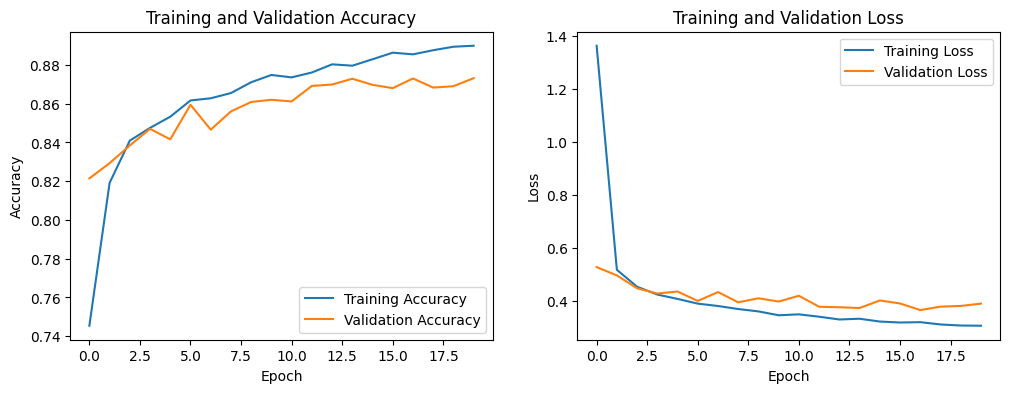

In [32]:
# Extract training and validation metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()